In [3]:
import snowflake.connector
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from snowflake_config import SNOWFLAKE_CONFIG

conn = snowflake.connector.connect(**SNOWFLAKE_CONFIG)
cursor = conn.cursor()

def run_query(sql):
    cursor.execute(sql)
    df = cursor.fetch_pandas_all()
    return df

print("Connected!")

Connected!


In [2]:
## A/B Test: Morning vs Evening Purchase Value
'''
This is a simulated A/B test as this dataset wasn't originally created for A/B testing.

In this test we will answer a question "Do users who purchase in the evening convert at a higher average order value than users who purchase 
in the morning?"

Null hypothesis (H0): evening and morning session revenue are equal
Alternative hypothesis (H1): evening session revenue is higher than morning

Groups:
- Control (A): Morning purchases (6am - 11:59am)
- Treatment (B): Evening purchases (6pm - 10:59pm)

Metric: Session revenue (total spend per purchase session)

Test: Mann-Whitney U (non-parametric, no normality assumption)

Significance threshold: p < 0.05

Decision rule: If p < 0.05 AND median difference > $10, recommend prioritizing evening engagement features
'''

'\nThis is a simulated A/B test as this dataset wasn\'t originally created for A/B testing.\n\nIn this test we will answer a question "Do users who purchase in the evening convert at a higher average order value than users who purchase \nin the morning?"\n'

In [4]:
ab_df = run_query("""
    select
        session_revenue,
        time_of_day,
        hour_of_day,
        user_type,
        cohort_month
    from fct_purchases
    where time_of_day in ('1. Morning', '3. Evening')
    and session_revenue > 0
""")

print(f"Total rows: {len(ab_df):,}")
print(ab_df['TIME_OF_DAY'].value_counts())

Total rows: 2,644,063
TIME_OF_DAY
3. Evening    2061568
1. Morning     582495
Name: count, dtype: int64


In [5]:
# sample and split groups
import numpy as np
from scipy import stats

# split into groups
morning = ab_df[ab_df['TIME_OF_DAY'] == '1. Morning']['SESSION_REVENUE']
evening = ab_df[ab_df['TIME_OF_DAY'] == '3. Evening']['SESSION_REVENUE']

# sample evening to match morning size
np.random.seed(42)  # for reproducibility
evening_sampled = evening.sample(n=len(morning), random_state=42)

print(f"Morning group:  {len(morning):,} sessions")
print(f"Evening group:  {len(evening_sampled):,} sessions (sampled)")
print(f"\nMorning median:  ${morning.median():,.2f}")
print(f"Evening median:  ${evening_sampled.median():,.2f}")
print(f"\nMorning mean:  ${morning.mean():,.2f}")
print(f"Evening mean:  ${evening_sampled.mean():,.2f}")

Morning group:  582,495 sessions
Evening group:  582,495 sessions (sampled)

Morning median:  $235.60
Evening median:  $249.71

Morning mean:  $512.26
Evening mean:  $529.48


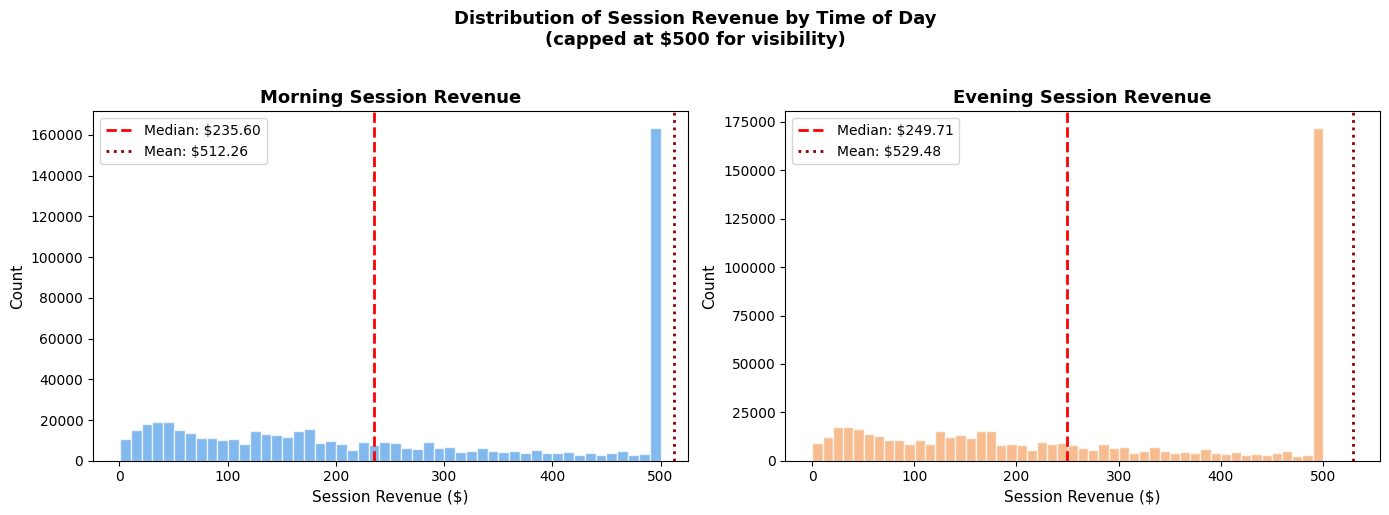

In [6]:
#distribution vasualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram — cap at 500 to see the main distribution
for ax, data, label, color in zip(
    axes,
    [morning, evening_sampled],
    ['Morning', 'Evening'],
    ['#4C9BE8', '#F4A261']
):
    ax.hist(
        data.clip(upper=500),
        bins=50,
        color=color,
        alpha=0.7,
        edgecolor='white'
    )
    ax.axvline(
        data.median(),
        color='red',
        linestyle='--',
        linewidth=2,
        label=f'Median: ${data.median():.2f}'
    )
    ax.axvline(
        data.mean(),
        color='darkred',
        linestyle=':',
        linewidth=2,
        label=f'Mean: ${data.mean():.2f}'
    )
    ax.set_title(f'{label} Session Revenue', fontsize=13, fontweight='bold')
    ax.set_xlabel('Session Revenue ($)', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.legend(fontsize=10)

plt.suptitle(
    'Distribution of Session Revenue by Time of Day\n(capped at $500 for visibility)',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

In [7]:
# Mann-Whitney test

from scipy.stats import mannwhitneyu

# run mann-whitney u test (one-tailed: evening > morning)
stat, p_value = mannwhitneyu(
    evening_sampled,
    morning,
    alternative='greater'  # one-tailed: testing if evening > morning
)

# effect size — rank biserial correlation
n1 = len(evening_sampled)
n2 = len(morning)
effect_size = 1 - (2 * stat) / (n1 * n2)

print("=" * 50)
print("Mann-Whitney U Test Results")
print("=" * 50)
print(f"U statistic:        {stat:,.0f}")
print(f"P-value:            {p_value:.6f}")
print(f"Effect size (r):    {effect_size:.4f}")
print()
print("Interpretation:")
print(f"  Median morning:   ${morning.median():,.2f}")
print(f"  Median evening:   ${evening_sampled.median():,.2f}")
print(f"  Median diff:      ${evening_sampled.median() - morning.median():,.2f}")
print(f"  Relative diff:    {(evening_sampled.median() - morning.median()) / morning.median() * 100:.1f}%")
print()
if p_value < 0.05:
    print("✓ Result is statistically significant (p < 0.05)")
else:
    print("✗ Result is NOT statistically significant (p >= 0.05)")
    
print()
# effect size interpretation
if abs(effect_size) < 0.1:
    effect_label = "negligible"
elif abs(effect_size) < 0.3:
    effect_label = "small"
elif abs(effect_size) < 0.5:
    effect_label = "medium"
else:
    effect_label = "large"
print(f"Effect size is {effect_label} (r = {effect_size:.4f})")

Mann-Whitney U Test Results
U statistic:        174,422,834,300
P-value:            0.000000
Effect size (r):    -0.0281

Interpretation:
  Median morning:   $235.60
  Median evening:   $249.71
  Median diff:      $14.11
  Relative diff:    6.0%

✓ Result is statistically significant (p < 0.05)

Effect size is negligible (r = -0.0281)


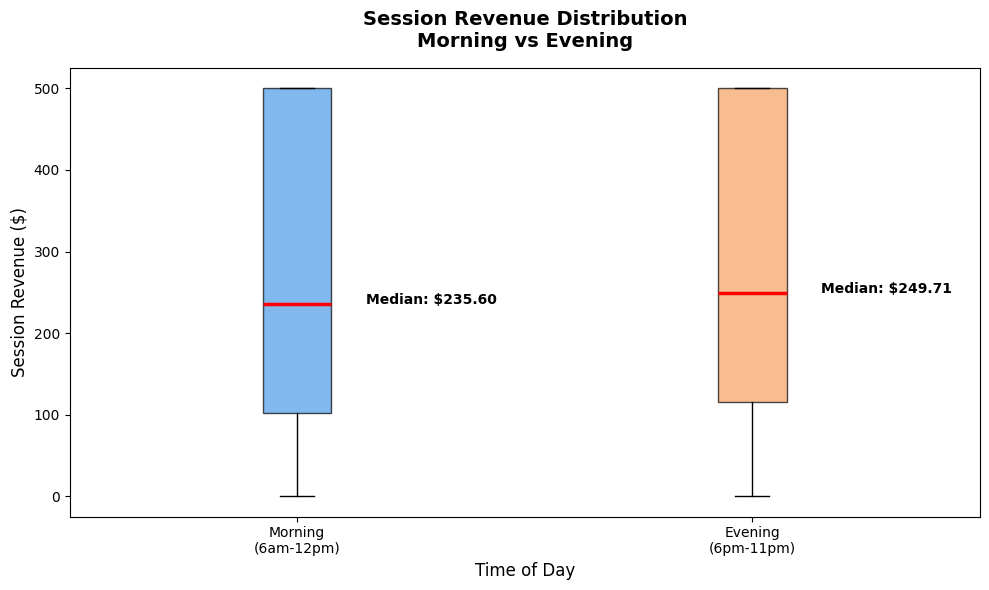

In [9]:
# visualize the result

fig, ax = plt.subplots(figsize=(10, 6))

# box plot comparison
data_to_plot = [
    morning.clip(upper=500),
    evening_sampled.clip(upper=500)
]

bp = ax.boxplot(
    data_to_plot,
    tick_labels=['Morning\n(6am-12pm)', 'Evening\n(6pm-11pm)'],
    patch_artist=True,
    medianprops=dict(color='red', linewidth=2.5)
)

bp['boxes'][0].set_facecolor('#4C9BE8')
bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor('#F4A261')
bp['boxes'][1].set_alpha(0.7)

ax.set_title(
    'Session Revenue Distribution\nMorning vs Evening',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_ylabel('Session Revenue ($)', fontsize=12)
ax.set_xlabel('Time of Day', fontsize=12)

# add median annotations
for i, data in enumerate([morning, evening_sampled], 1):
    ax.annotate(
        f'Median: ${data.median():,.2f}',
        xy=(i, data.median()),
        xytext=(i + 0.15, data.median()),
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

In [ ]:
## A/B Test Results & Interpretation

### Statistical Results
'''
| Metric         | Morning | Evening | Difference          |
|----------------|---------|---------|---------------------|
| Median revenue | $235.60 | $249.71 | +$14.11 (+6%)       |
| Mean revenue   | $512.26 | $529.48 | +$17.22 (+3%)       |
| P-value        |         |         | 0.000000            |
| Effect size (r)|         |         | -0.028 (negligible) |

### Key Finding
The result is statistically significant but practically negligible.

With 582,000 sessions per group, even trivial differences register as significant — this is the large sample problem 
in A/B testing. The effect size of r = 0.028 is negligible by conventional standards (< 0.1).

### Business Recommendation
Do not prioritize evening-specific features based on this finding. A $14 median difference does not justify engineering investment. 
Resources would be better spent on interventions with larger expected impact — such as reducing cart abandonment (43% rate 
identified in funnel analysis) or re-engaging December/March cohorts identified in retention analysis.

### Methodological Notes
- Mann-Whitney U used because revenue distributions are heavily right-skewed (mean ~2x median)
- Evening group downsampled to 582K to match morning group size
- One-tailed test used as hypothesis was directional
- p-value alone is insufficient — effect size is essential for practical decision making'''